# Compare YOLO vs Faster R-CNN


In [1]:
from pathlib import Path
import os
import time
import random
import json
import re

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

try:
    import cv2
except ImportError as e:
    raise ImportError("Please install opencv-python: pip install opencv-python") from e


In [11]:
# ============================================================
# USER VARIABLES
# ============================================================

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent

#directory for the data
DATASET_DIR = PROJECT_ROOT / "data" / "f110_dataset_20220209"

# Split/checkpoint/result folders
SPLIT_DIR = PROJECT_ROOT / "splits"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
METRIC_DIR = RESULTS_DIR / "metrics"

# Common image size used in your YOLO notebook and Faster R-CNN notebook.
IMG_HEIGHT = 180
IMG_WIDTH = 320

# Same split settings used in training. If split files already exist, they are reused.
SEED = 42
TRAIN_FRAC = 0.80

# Evaluation settings
BATCH_SIZE_EVAL = 1          # Use 1 for realistic per-frame timing.
NUM_WORKERS = 0              # Keep 0 on Windows/Jupyter.
IOU_THRESHOLD = 0.50
SCORE_THRESHOLDS = [0.30, 0.50, 0.70]
MAIN_SCORE_THRESHOLD = 0.50

# Speed test settings
NUM_WARMUP_IMAGES = 20       # Warm up CUDA before timing.
MAX_TIMED_IMAGES = None      # Set to e.g. 100 for faster testing; None uses full validation set.

# Qualitative figure settings
NUM_QUALITATIVE_IMAGES = 6

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

for d in [SPLIT_DIR, CHECKPOINT_DIR, FIGURE_DIR, METRIC_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(CURRENT_DIR)
print("Device:", DEVICE)


c:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\notebooks
Device: cpu


## 1. Load validation split


In [12]:
LABELS = np.load(DATASET_DIR / "labels.npy").astype(np.float32)

print("Dataset directory:", DATASET_DIR)
print("Number of labels:", len(LABELS))
print("First label [cx, cy, w, h]:", LABELS[0])


Dataset directory: c:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\data\f110_dataset_20220209
Number of labels: 1792
First label [cx, cy, w, h]: [238.5 167.5 147.  103. ]


In [13]:
train_indices_path = SPLIT_DIR / "train_indices.npy"
val_indices_path = SPLIT_DIR / "val_indices.npy"

train_indices = np.load(train_indices_path)
val_indices = np.load(val_indices_path)
print("Loaded existing train/validation split.")

# split_summary = {
#     "num_total": int(len(LABELS)),
#     "num_train": int(len(train_indices)),
#     "num_val": int(len(val_indices)),
#     "seed": int(SEED),
#     "train_frac": float(TRAIN_FRAC),
# }

with open(SPLIT_DIR / "split_summary_compare_notebook.json", "r") as f:
    data = json.load(f)
    print(data)
print("Overlap count:", len(set(train_indices.tolist()).intersection(set(val_indices.tolist()))))


Loaded existing train/validation split.
{'num_total': 1792, 'num_train': 1433, 'num_val': 359, 'seed': 42, 'train_frac': 0.8}
Overlap count: 0


## 2. Utility functions and dataset


In [14]:
def cxcywh_to_xyxy(box):
    cx, cy, w, h = [float(x) for x in box]
    return np.array([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2], dtype=np.float32)


def xyxy_to_cxcywh(box):
    x1, y1, x2, y2 = [float(x) for x in box]
    return np.array([(x1 + x2) / 2, (y1 + y2) / 2, x2 - x1, y2 - y1], dtype=np.float32)


def clip_xyxy(box, width=IMG_WIDTH, height=IMG_HEIGHT):
    box = np.array(box, dtype=np.float32).copy()
    box[0] = np.clip(box[0], 0, width - 1)
    box[1] = np.clip(box[1], 0, height - 1)
    box[2] = np.clip(box[2], 0, width - 1)
    box[3] = np.clip(box[3], 0, height - 1)
    if box[2] <= box[0]:
        box[2] = min(width - 1, box[0] + 1)
    if box[3] <= box[1]:
        box[3] = min(height - 1, box[1] + 1)
    return box


def box_iou_matrix(boxes_a, boxes_b):
    boxes_a = np.asarray(boxes_a, dtype=np.float32)
    boxes_b = np.asarray(boxes_b, dtype=np.float32)

    if len(boxes_a) == 0 or len(boxes_b) == 0:
        return np.zeros((len(boxes_a), len(boxes_b)), dtype=np.float32)

    x1 = np.maximum(boxes_a[:, None, 0], boxes_b[None, :, 0])
    y1 = np.maximum(boxes_a[:, None, 1], boxes_b[None, :, 1])
    x2 = np.minimum(boxes_a[:, None, 2], boxes_b[None, :, 2])
    y2 = np.minimum(boxes_a[:, None, 3], boxes_b[None, :, 3])

    inter = np.maximum(0, x2 - x1) * np.maximum(0, y2 - y1)

    area_a = np.maximum(0, boxes_a[:, 2] - boxes_a[:, 0]) * np.maximum(0, boxes_a[:, 3] - boxes_a[:, 1])
    area_b = np.maximum(0, boxes_b[:, 2] - boxes_b[:, 0]) * np.maximum(0, boxes_b[:, 3] - boxes_b[:, 1])

    union = area_a[:, None] + area_b[None, :] - inter + 1e-9
    return inter / union


In [15]:
class F110CompareDataset(Dataset):
    # Returns both image formats:
    #   yolo_image: BGR tensor, matching the original YOLO notebook's cv2.imread pipeline
    #   frcnn_image: RGB tensor, matching TorchVision detection conventions
    #   target: ground-truth box in resized image xyxy format
    def __init__(self, dataset_dir, labels, indices, img_width=320, img_height=180):
        self.dataset_dir = Path(dataset_dir)
        self.labels = labels.astype(np.float32)
        self.indices = np.asarray(indices, dtype=int)
        self.img_width = int(img_width)
        self.img_height = int(img_height)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        sample_idx = int(self.indices[idx])
        img_path = self.dataset_dir / f"{sample_idx}.jpg"

        # YOLO format: original notebook used cv2.imread, which loads BGR.
        bgr = cv2.imread(str(img_path))
        if bgr is None:
            raise FileNotFoundError(f"Could not read image: {img_path}")

        original_h, original_w = bgr.shape[:2]
        bgr_resized = cv2.resize(bgr, (self.img_width, self.img_height))
        bgr_float = bgr_resized.astype(np.float32) / 255.0
        yolo_image = torch.from_numpy(np.transpose(bgr_float, (2, 0, 1))).float()

        # Faster R-CNN format: RGB tensor.
        rgb_resized = cv2.cvtColor(bgr_resized, cv2.COLOR_BGR2RGB)
        frcnn_image = torchvision.transforms.functional.to_tensor(rgb_resized)

        # Scale label from original image coordinates to resized image coordinates.
        label = self.labels[sample_idx].copy()
        scale_x = self.img_width / original_w
        scale_y = self.img_height / original_h

        label[0] *= scale_x
        label[2] *= scale_x
        label[1] *= scale_y
        label[3] *= scale_y

        gt_box = clip_xyxy(cxcywh_to_xyxy(label), self.img_width, self.img_height)

        target = {
            "boxes": torch.tensor([gt_box], dtype=torch.float32),
            "labels": torch.tensor([1], dtype=torch.int64),
            "image_id": torch.tensor([sample_idx], dtype=torch.int64),
        }

        return {
            "yolo_image": yolo_image,
            "frcnn_image": frcnn_image,
            "target": target,
            "sample_idx": sample_idx,
            "display_rgb": rgb_resized,
        }


def compare_collate_fn(batch):
    yolo_images = torch.stack([item["yolo_image"] for item in batch], dim=0)
    frcnn_images = [item["frcnn_image"] for item in batch]
    targets = [item["target"] for item in batch]
    sample_indices = [item["sample_idx"] for item in batch]
    display_rgbs = [item["display_rgb"] for item in batch]
    return yolo_images, frcnn_images, targets, sample_indices, display_rgbs


val_dataset = F110CompareDataset(
    dataset_dir=DATASET_DIR,
    labels=LABELS,
    indices=val_indices,
    img_width=IMG_WIDTH,
    img_height=IMG_HEIGHT,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE_EVAL,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=compare_collate_fn,
    pin_memory=PIN_MEMORY,
)

print("Validation images:", len(val_dataset))
print("Validation batches:", len(val_loader))


Validation images: 359
Validation batches: 359


## 3. Load the YOLO Model


In [16]:
# These are the same dimensions used in the original YOLO notebook.
final_dim = [5, 10]          # [rows, cols]
input_dim = [IMG_HEIGHT, IMG_WIDTH]
anchor_size = [(input_dim[0] / final_dim[0]), (input_dim[1] / final_dim[1])]


def grid_cell(cell_indx, cell_indy):
    stride_0 = anchor_size[1]
    stride_1 = anchor_size[0]
    return np.array([
        cell_indx * stride_0,
        cell_indy * stride_1,
        cell_indx * stride_0 + stride_0,
        cell_indy * stride_1 + stride_1
    ], dtype=np.float32)


def bbox_convert(c_x, c_y, w, h):
    return [c_x - w / 2, c_y - h / 2, c_x + w / 2, c_y + h / 2]


class F110_YOLO(torch.nn.Module):
    def __init__(self):
        super(F110_YOLO, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=4, padding=1, stride=2)
        self.batchnorm1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=4, padding=1, stride=2)
        self.batchnorm2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 32, kernel_size=4, padding=1, stride=2)
        self.batchnorm3 = nn.BatchNorm2d(32)

        self.conv4 = nn.Conv2d(32, 64, kernel_size=4, padding=1, stride=2)
        self.batchnorm4 = nn.BatchNorm2d(64)

        self.conv5 = nn.Conv2d(64, 64, kernel_size=4, padding=1, stride=2)
        self.batchnorm5 = nn.BatchNorm2d(64)

        self.conv6 = nn.Conv2d(64, 32, kernel_size=3, padding=1, stride=1)
        self.batchnorm6 = nn.BatchNorm2d(32)

        self.conv7 = nn.ConvTranspose2d(32, 32, kernel_size=3, padding=1, stride=1)
        self.batchnorm7 = nn.BatchNorm2d(32)

        self.conv8 = nn.ConvTranspose2d(32, 16, kernel_size=3, padding=1, stride=1)
        self.batchnorm8 = nn.BatchNorm2d(16)

        self.conv9 = nn.Conv2d(16, 5, kernel_size=1, padding=0, stride=1)

    def forward(self, x):
        x = torch.relu(self.batchnorm1(self.conv1(x)))
        x = torch.relu(self.batchnorm2(self.conv2(x)))
        x = torch.relu(self.batchnorm3(self.conv3(x)))
        x = torch.relu(self.batchnorm4(self.conv4(x)))
        x = torch.relu(self.batchnorm5(self.conv5(x)))
        x = torch.relu(self.batchnorm6(self.conv6(x)))
        x = torch.relu(self.batchnorm7(self.conv7(x)))
        x = torch.relu(self.batchnorm8(self.conv8(x)))
        x = self.conv9(x)

        # Matches the original notebook: objectness and xy offsets are raw;
        # width and height are passed through sigmoid.
        x = torch.cat([x[:, 0:3, :, :], torch.sigmoid(x[:, 3:5, :, :])], dim=1)
        return x


def decode_yolo_single(result_single, score_threshold=0.50):
    # result_single shape: [5, 5, 10]
    # Returns boxes [N, 4] in xyxy and scores [N].
    if torch.is_tensor(result_single):
        result_single = result_single.detach().cpu().numpy()

    boxes = []
    scores = []

    for ind_row in range(final_dim[0]):
        for ind_col in range(final_dim[1]):
            score = float(result_single[0, ind_row, ind_col])

            if score >= score_threshold:
                grid_info = grid_cell(ind_col, ind_row)

                c_x = grid_info[0] + anchor_size[1] / 2 + float(result_single[1, ind_row, ind_col])
                c_y = grid_info[1] + anchor_size[0] / 2 + float(result_single[2, ind_row, ind_col])
                w = float(result_single[3, ind_row, ind_col]) * input_dim[1]
                h = float(result_single[4, ind_row, ind_col]) * input_dim[0]

                box = clip_xyxy(bbox_convert(c_x, c_y, w, h), IMG_WIDTH, IMG_HEIGHT)
                boxes.append(box)
                scores.append(score)

    if len(boxes) == 0:
        return np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.float32)

    return np.asarray(boxes, dtype=np.float32), np.asarray(scores, dtype=np.float32)


Load the YOLO checkpoint weights

In [18]:
yolo_ckpt = CURRENT_DIR / 'model_300.pt'
yolo_model = F110_YOLO().to(DEVICE)
state = torch.load(yolo_ckpt, map_location=DEVICE)

yolo_model.load_state_dict(state)
yolo_model.eval()

print("Loaded YOLO checkpoint:", yolo_ckpt)


Loaded YOLO checkpoint: c:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\notebooks\model_300.pt


## 4. Load the Faster R-CNN Model


In [20]:
def build_fasterrcnn_model(num_classes=2):
    # weights=None avoids trying to download pretrained weights.
    model = fasterrcnn_mobilenet_v3_large_fpn(
        weights=None,
        weights_backbone=None,
        min_size=IMG_HEIGHT,
        max_size=IMG_WIDTH,
    )

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


frcnn_ckpt = CHECKPOINT_DIR / 'fasterrcnn_best.pt'

frcnn_model = build_fasterrcnn_model(num_classes=2).to(DEVICE) #two classes: 1 = car 0 = background
state = torch.load(frcnn_ckpt, map_location=DEVICE) 

frcnn_model.load_state_dict(state)
frcnn_model.eval()

print("Loaded Faster R-CNN checkpoint:", frcnn_ckpt)


Loaded Faster R-CNN checkpoint: c:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\checkpoints\fasterrcnn_best.pt


## 5. Evaluation and timing functions

The speed measurement reports **milliseconds per image** on the validation set to get the inference time.

In [21]:
@torch.no_grad()
def predict_yolo_batch(model, yolo_images, score_threshold):
    model.eval()
    yolo_images = yolo_images.to(DEVICE)

    outputs = model(yolo_images)
    batch_boxes = []
    batch_scores = []

    for i in range(outputs.shape[0]):
        boxes, scores = decode_yolo_single(outputs[i], score_threshold=score_threshold)
        batch_boxes.append(boxes)
        batch_scores.append(scores)

    return batch_boxes, batch_scores


@torch.no_grad()
def predict_frcnn_batch(model, frcnn_images, score_threshold):
    model.eval()
    frcnn_images = [img.to(DEVICE) for img in frcnn_images]

    outputs = model(frcnn_images)

    batch_boxes = []
    batch_scores = []

    for output in outputs:
        boxes = output["boxes"].detach().cpu().numpy().astype(np.float32)
        scores = output["scores"].detach().cpu().numpy().astype(np.float32)

        keep = scores >= score_threshold
        boxes = boxes[keep]
        scores = scores[keep]

        batch_boxes.append(boxes)
        batch_scores.append(scores)

    return batch_boxes, batch_scores


def compute_ap50_from_predictions(all_pred_records, num_gt, iou_threshold=0.50):
    # all_pred_records: list of dicts with keys: score, is_tp
    if len(all_pred_records) == 0:
        return 0.0

    records = sorted(all_pred_records, key=lambda x: x["score"], reverse=True)
    tp = np.array([r["is_tp"] for r in records], dtype=np.float32)
    fp = 1.0 - tp

    cum_tp = np.cumsum(tp)
    cum_fp = np.cumsum(fp)

    precision_curve = cum_tp / np.maximum(cum_tp + cum_fp, 1e-9)
    recall_curve = cum_tp / max(num_gt, 1)

    ap = 0.0
    for r in np.linspace(0, 1, 101):
        if np.any(recall_curve >= r):
            ap += np.max(precision_curve[recall_curve >= r]) / 101.0

    return float(ap)


@torch.no_grad()
def evaluate_model(model, model_name, data_loader, score_threshold=0.50, iou_threshold=0.50):
    model.eval()

    all_pred_records = []
    total_gt = 0
    total_predictions = 0
    total_tp = 0
    total_fp = 0
    missed_images = 0
    matched_ious = []
    best_ious_per_image = []

    inference_times = []
    timed_images = 0

    # Warm-up loop
    warmup_seen = 0
    for yolo_images, frcnn_images, targets, sample_indices, display_rgbs in data_loader:
        if warmup_seen >= NUM_WARMUP_IMAGES:
            break

        if model_name == "YOLO":
            _ = predict_yolo_batch(model, yolo_images, score_threshold)
            warmup_seen += yolo_images.shape[0]
        else:
            _ = predict_frcnn_batch(model, frcnn_images, score_threshold)
            warmup_seen += len(frcnn_images)

    if DEVICE.type == "cuda":
        torch.cuda.synchronize() # so asynchronous CUDA execution does not make the model look artificially fast.

    for yolo_images, frcnn_images, targets, sample_indices, display_rgbs in tqdm(
        data_loader, desc=f"Evaluating {model_name} thr={score_threshold}", leave=False
    ):
        batch_size = len(targets)

        if MAX_TIMED_IMAGES is not None and timed_images >= MAX_TIMED_IMAGES:
            break

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        t0 = time.perf_counter()

        if model_name == "YOLO":
            batch_boxes, batch_scores = predict_yolo_batch(model, yolo_images, score_threshold)
        elif model_name == "Faster R-CNN":
            batch_boxes, batch_scores = predict_frcnn_batch(model, frcnn_images, score_threshold)
        else:
            raise ValueError(f"Unknown model name: {model_name}")

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        dt = time.perf_counter() - t0
        inference_times.append(dt / batch_size)
        timed_images += batch_size

        for boxes, scores, target in zip(batch_boxes, batch_scores, targets):
            gt_boxes = target["boxes"].detach().cpu().numpy().astype(np.float32)
            total_gt += len(gt_boxes)

            total_predictions += len(boxes)

            if len(boxes) == 0:
                missed_images += 1
                best_ious_per_image.append(0.0)
                continue

            order = np.argsort(-scores)
            boxes = boxes[order]
            scores = scores[order]

            ious = box_iou_matrix(boxes, gt_boxes)
            used_gt = set()

            best_ious_per_image.append(float(np.max(ious)) if ious.size > 0 else 0.0)

            for pred_i in range(len(boxes)):
                if len(gt_boxes) == 0:
                    total_fp += 1
                    all_pred_records.append({"score": float(scores[pred_i]), "is_tp": 0})
                    continue

                best_gt_i = int(np.argmax(ious[pred_i]))
                best_iou = float(ious[pred_i, best_gt_i])

                if best_iou >= iou_threshold and best_gt_i not in used_gt:
                    total_tp += 1
                    used_gt.add(best_gt_i)
                    matched_ious.append(best_iou)
                    all_pred_records.append({"score": float(scores[pred_i]), "is_tp": 1})
                else:
                    total_fp += 1
                    all_pred_records.append({"score": float(scores[pred_i]), "is_tp": 0})

    precision = total_tp / max(total_tp + total_fp, 1)
    recall = total_tp / max(total_gt, 1)
    ap50 = compute_ap50_from_predictions(all_pred_records, total_gt, iou_threshold=iou_threshold)

    return {
        "model": model_name,
        "score_threshold": float(score_threshold),
        "AP50": float(ap50),
        "precision": float(precision),
        "recall": float(recall),
        "mean_matched_iou": float(np.mean(matched_ious)) if len(matched_ious) > 0 else 0.0,
        "mean_best_iou_per_image": float(np.mean(best_ious_per_image)) if len(best_ious_per_image) > 0 else 0.0,
        "miss_rate": float(missed_images / max(total_gt, 1)),
        "num_predictions": int(total_predictions),
        "num_ground_truth": int(total_gt),
        "mean_inference_ms": 1000.0 * float(np.mean(inference_times)) if len(inference_times) > 0 else np.nan,
        "median_inference_ms": 1000.0 * float(np.median(inference_times)) if len(inference_times) > 0 else np.nan,
    }


## 6. Run evaluation for all thresholds to get ablations


In [22]:
rows = []

for thr in SCORE_THRESHOLDS:
    rows.append(evaluate_model(yolo_model, "YOLO", val_loader, score_threshold=thr, iou_threshold=IOU_THRESHOLD))
    rows.append(evaluate_model(frcnn_model, "Faster R-CNN", val_loader, score_threshold=thr, iou_threshold=IOU_THRESHOLD))

metrics_df = pd.DataFrame(rows)

metrics_path = METRIC_DIR / "model_comparison_thresholds.csv"
metrics_df.to_csv(metrics_path, index=False)

display(metrics_df)
print("Saved:", metrics_path)


C:\Users\ishan\AppData\Local\Temp\ipykernel_17024\1021032460.py:47: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  "boxes": torch.tensor([gt_box], dtype=torch.float32),


Evaluating YOLO thr=0.3:   0%|          | 0/359 [00:00<?, ?it/s]

Evaluating Faster R-CNN thr=0.3:   0%|          | 0/359 [00:00<?, ?it/s]

Evaluating YOLO thr=0.5:   0%|          | 0/359 [00:00<?, ?it/s]

Evaluating Faster R-CNN thr=0.5:   0%|          | 0/359 [00:00<?, ?it/s]

Evaluating YOLO thr=0.7:   0%|          | 0/359 [00:00<?, ?it/s]

Evaluating Faster R-CNN thr=0.7:   0%|          | 0/359 [00:00<?, ?it/s]

,model,score_threshold,AP50,precision,recall,mean_matched_iou,mean_best_iou_per_image,miss_rate,num_predictions,num_ground_truth,mean_inference_ms,median_inference_ms
0,YOLO,0.3,0.242112,0.075464,0.974930,0.750564,0.847762,0.000000,4638,359,4.479343,4.2545
1,Faster R-CNN,0.3,0.999972,0.970270,1.000000,0.942455,0.942771,0.000000,370,359,44.837411,43.3789
2,YOLO,0.5,0.242112,0.095420,0.974930,0.750564,0.841666,0.008357,3668,359,4.314421,4.1099
3,Faster R-CNN,0.5,0.999972,0.975543,1.000000,0.942455,0.942771,0.000000,368,359,44.206309,42.6563
4,YOLO,0.7,0.234140,0.127861,0.902507,0.752885,0.781223,0.025070,2534,359,3.908857,3.6433
5,Faster R-CNN,0.7,0.999972,0.980874,1.000000,0.942455,0.942771,0.000000,366,359,44.980191,43.3155


Saved: c:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\results\metrics\model_comparison_thresholds.csv


Look at the comparison between the YOLO model and Faster R-CNN model for score threshold of 0.5

In [24]:
main_metrics_df = metrics_df[metrics_df["score_threshold"] == MAIN_SCORE_THRESHOLD].copy()
main_metrics_path = METRIC_DIR / "model_comparison_main_threshold.csv"
main_metrics_df.to_csv(main_metrics_path, index=False)

display(main_metrics_df)
print("Saved:", main_metrics_path)


,model,score_threshold,AP50,precision,recall,mean_matched_iou,mean_best_iou_per_image,miss_rate,num_predictions,num_ground_truth,mean_inference_ms,median_inference_ms
2,YOLO,0.5,0.242112,0.095420,0.97493,0.750564,0.841666,0.008357,3668,359,4.314421,4.1099
3,Faster R-CNN,0.5,0.999972,0.975543,1.00000,0.942455,0.942771,0.000000,368,359,44.206309,42.6563


Saved: c:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\results\metrics\model_comparison_main_threshold.csv


## 7. Make report figures


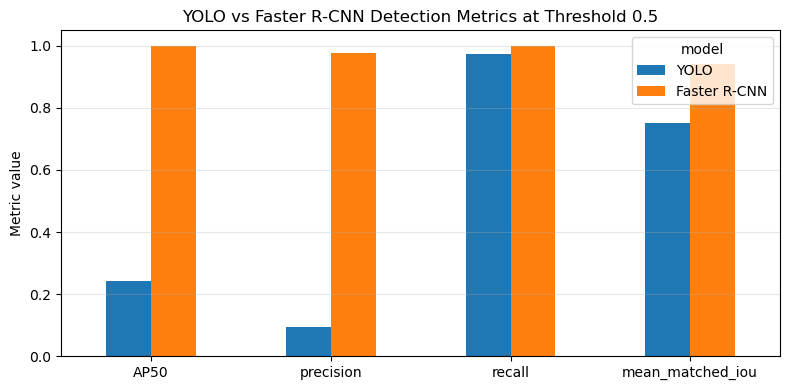

Saved: c:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\results\figures\model_metric_comparison.png


In [25]:
# Bar chart: AP50, Precision, Recall, Mean IoU at main threshold.
plot_metrics = ["AP50", "precision", "recall", "mean_matched_iou"]
plot_df = main_metrics_df.set_index("model")[plot_metrics]

ax = plot_df.T.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_ylabel("Metric value")
ax.set_title(f"YOLO vs Faster R-CNN Detection Metrics at Threshold {MAIN_SCORE_THRESHOLD}")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

fig_path = FIGURE_DIR / "model_metric_comparison.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)


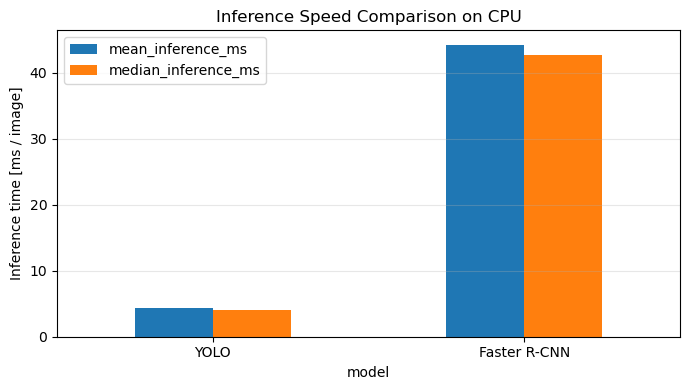

Saved: c:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\results\figures\model_speed_comparison.png


,model,mean_inference_ms,median_inference_ms
2,YOLO,4.314421,4.1099
3,Faster R-CNN,44.206309,42.6563


In [26]:
# Bar chart: inference time.
speed_df = main_metrics_df[["model", "mean_inference_ms", "median_inference_ms"]].copy()

ax = speed_df.set_index("model")[["mean_inference_ms", "median_inference_ms"]].plot(
    kind="bar",
    figsize=(7, 4),
    rot=0,
)
ax.set_ylabel("Inference time [ms / image]")
ax.set_title(f"Inference Speed Comparison on {DEVICE.type.upper()}")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

fig_path = FIGURE_DIR / "model_speed_comparison.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)
display(speed_df)


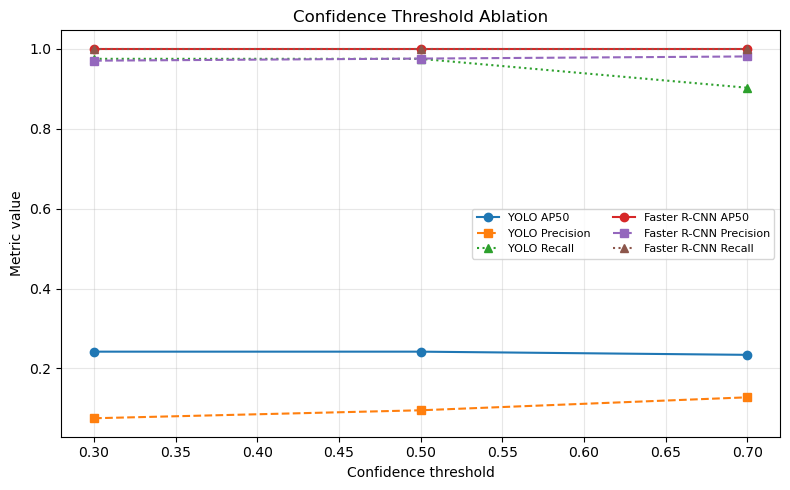

Saved: c:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\results\figures\threshold_ablation_comparison.png


In [27]:
# Threshold ablation comparison.
plt.figure(figsize=(8, 5))

for model_name in ["YOLO", "Faster R-CNN"]:
    sub = metrics_df[metrics_df["model"] == model_name].sort_values("score_threshold")
    plt.plot(sub["score_threshold"], sub["AP50"], marker="o", label=f"{model_name} AP50")
    plt.plot(sub["score_threshold"], sub["precision"], marker="s", linestyle="--", label=f"{model_name} Precision")
    plt.plot(sub["score_threshold"], sub["recall"], marker="^", linestyle=":", label=f"{model_name} Recall")

plt.xlabel("Confidence threshold")
plt.ylabel("Metric value")
plt.title("Confidence Threshold Ablation")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()

fig_path = FIGURE_DIR / "threshold_ablation_comparison.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)


## 8. Qualitative detection comparison figure


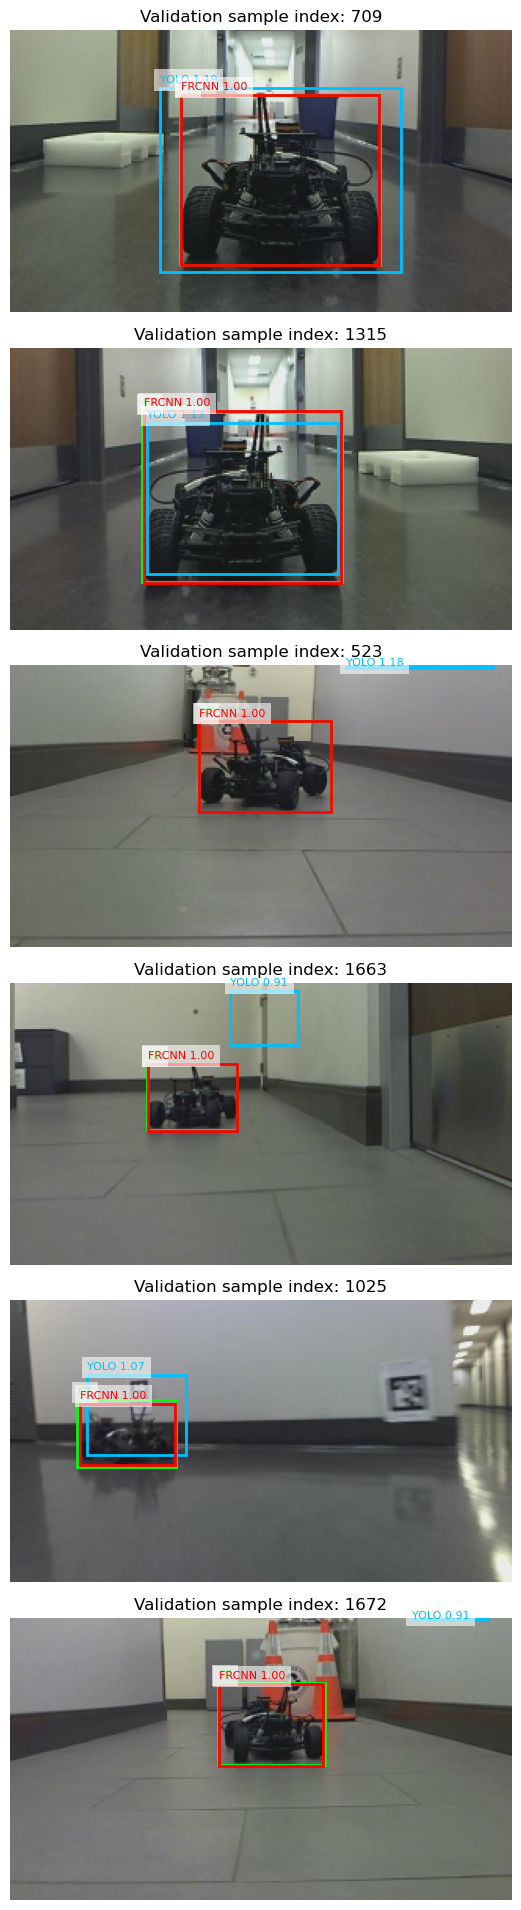

Saved: c:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\results\figures\qualitative_yolo_vs_fasterrcnn.png


In [29]:
@torch.no_grad()
def get_single_predictions_for_display(sample, score_threshold=0.50):
    yolo_img = sample["yolo_image"].unsqueeze(0).to(DEVICE)
    frcnn_img = [sample["frcnn_image"].to(DEVICE)]

    # YOLO
    yolo_out = yolo_model(yolo_img)[0].detach().cpu().numpy()
    yolo_boxes, yolo_scores = decode_yolo_single(yolo_out, score_threshold=score_threshold)

    # Faster R-CNN
    frcnn_out = frcnn_model(frcnn_img)[0]
    frcnn_boxes = frcnn_out["boxes"].detach().cpu().numpy().astype(np.float32)
    frcnn_scores = frcnn_out["scores"].detach().cpu().numpy().astype(np.float32)
    keep = frcnn_scores >= score_threshold
    frcnn_boxes = frcnn_boxes[keep]
    frcnn_scores = frcnn_scores[keep]

    return yolo_boxes, yolo_scores, frcnn_boxes, frcnn_scores


def draw_box(ax, box, color, label=None, linewidth=2):
    x1, y1, x2, y2 = [float(x) for x in box]
    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=linewidth,
        edgecolor=color,
        facecolor="none",
    )
    ax.add_patch(rect)
    if label is not None:
        ax.text(
            x1,
            max(0, y1 - 3),
            label,
            color=color,
            fontsize=8,
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"),
        )


sample_indices = np.linspace(0, len(val_dataset) - 1, min(NUM_QUALITATIVE_IMAGES, len(val_dataset)), dtype=int)

fig, axes = plt.subplots(len(sample_indices), 1, figsize=(8, 3.2 * len(sample_indices)))
if len(sample_indices) == 1:
    axes = [axes]

for ax, dataset_i in zip(axes, sample_indices):
    sample = val_dataset[int(dataset_i)]
    rgb = sample["display_rgb"]
    gt_box = sample["target"]["boxes"][0].numpy()

    yolo_boxes, yolo_scores, frcnn_boxes, frcnn_scores = get_single_predictions_for_display(
        sample,
        score_threshold=MAIN_SCORE_THRESHOLD,
    )

    ax.imshow(rgb)

    # Ground truth in green
    draw_box(ax, gt_box, "lime", "GT", linewidth=2)

    # Show top YOLO prediction in blue
    if len(yolo_boxes) > 0:
        best = int(np.argmax(yolo_scores))
        draw_box(ax, yolo_boxes[best], "deepskyblue", f"YOLO {yolo_scores[best]:.2f}", linewidth=2)
    else:
        ax.text(5, 15, "YOLO: no det", color="deepskyblue", fontsize=9,
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))

    # Show top Faster R-CNN prediction in red
    if len(frcnn_boxes) > 0:
        best = int(np.argmax(frcnn_scores))
        draw_box(ax, frcnn_boxes[best], "red", f"FRCNN {frcnn_scores[best]:.2f}", linewidth=2)
    else:
        ax.text(5, 30, "FRCNN: no det", color="red", fontsize=9,
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))

    ax.set_title(f"Validation sample index: {sample['sample_idx']}")
    ax.axis("off")

plt.tight_layout()
fig_path = FIGURE_DIR / "qualitative_yolo_vs_fasterrcnn.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)
